# 1. KHAI BÁO DỮ LIỆU


In [117]:
# =============================================================================
# MỤC TIÊU
# - Thiết lập môi trường phân tích dữ liệu cho toàn bộ project
# - Import các thư viện cốt lõi phục vụ xử lý dữ liệu, trực quan hóa
# - Load dữ liệu giá ETH/USDT để bắt đầu quá trình phân tích và xây dựng chiến lược
# =============================================================================

# =============================================================================
# IMPORT THƯ VIỆN
# - pandas: xử lý dữ liệu dạng bảng và chuỗi thời gian (time series)
# - numpy: tính toán số học, vector hóa
# - matplotlib, seaborn: trực quan hóa dữ liệu để khám phá đặc điểm thị trường
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# LOAD DỮ LIỆU
# - Đọc dữ liệu ETH/USDT từ file CSV
# - Dữ liệu bao gồm các thông tin thị trường như giá và khối lượng giao dịch
# - Đây là dữ liệu đầu vào ban đầu cho toàn bộ pipeline:
#   tiền xử lý → feature engineering → modeling → backtest
# =============================================================================
df = pd.read_csv(r"C:\Users\admin\Documents\NEU\KHDL\ETHUSDT (1).csv")

# =============================================================================
# KHÁM PHÁ NHANH DỮ LIỆU
# - Hiển thị 5 dòng đầu tiên để:
#   + Kiểm tra cấu trúc dữ liệu
#   + Xác nhận các cột (timestamp, open, high, low, close, volume, ...)
#   + Đảm bảo dữ liệu được load đúng trước khi xử lý tiếp
# =============================================================================
display(df.head())


,timestamp,open,high,low,close,volume
0,2019-11-27 07:30:00,146.00,146.00,146.00,146.00,0.01
1,2019-11-27 08:00:00,125.03,125.03,125.03,125.03,0.01
2,2019-11-27 08:30:00,145.00,145.01,133.00,133.00,0.07
3,2019-11-27 09:00:00,133.00,133.00,133.00,133.00,0.00
4,2019-11-27 09:30:00,133.00,133.00,133.00,133.00,0.00


#2. TIỀN XỬ LÝ DỮ LIỆU

In [118]:
# MỤC TIÊU
# - Kiểm tra nhanh quy mô dữ liệu sau khi load
# - Xác nhận số lượng quan sát (observations) thực tế dùng cho phân tích
row_count_excluding_first = df.shape[0]
print(f"Tổng số dòng (trừ dòng đầu tiên): {row_count_excluding_first}") # Trừ dòng đầu tiên vì đó là tên cột

Tổng số dòng (trừ dòng đầu tiên): 100222


In [119]:
df['timestamp'] = pd.to_datetime(df['timestamp'])   # Chuyển định dạng ngày cho cột timestamp
df.set_index('timestamp', inplace=True)
df.sort_index(inplace=True) # đưa timestamp làm chỉ số cho các quan sát


In [120]:

    # Nhận thấy có một số quan sát có Volume = 0, nên biến đổi chúng thành 0.0001
    # Lý do 1: Tránh lỗi chia cho 0 khi tính một số chỉ báo liên quan đến tỷ lệ volume (ví dụ: Volume Ratio = Vol / MA_Vol).
    # Lý do 2: Tránh lỗi ra vô cực âm nếu sau này áp dụng logarit (Log Volume).
    # Lý do 3: Giúp mô hình ML không bị nhiễu bởi các giá trị 0 tuyệt đối
    # (thay bằng epsilon 0.0001 giữ nguyên ý nghĩa là "rất nhỏ" nhưng vẫn tính toán được).
df['volume'] = df['volume'].replace(0, 0.0001)

    # Resample để đảm bảo dữ liệu liên tục (khung 30 phút)
    # Nếu thiếu dòng nào sẽ tự động điền bằng giá trị trước đó (ffill)
    # Điều này quan trọng để duy trì cấu trúc chuỗi thời gian cho các chỉ báo kỹ thuật (Indicator).
df = df.asfreq('30min', method='ffill')

df.head(5)


,open,high,low,close,volume
timestamp,,,,,
2019-11-27 07:30:00,146.00,146.00,146.00,146.00,0.0100
2019-11-27 08:00:00,125.03,125.03,125.03,125.03,0.0100
2019-11-27 08:30:00,145.00,145.01,133.00,133.00,0.0700
2019-11-27 09:00:00,133.00,133.00,133.00,133.00,0.0001
2019-11-27 09:30:00,133.00,133.00,133.00,133.00,0.0001


In [121]:
# kiểm tra lại số dòng của df sau khi tiền xử lý
row_count_excluding_first_1 = df.shape[0]
print(f"Tổng số dòng (trừ dòng đầu tiên): {row_count_excluding_first}")
# dữ liệu không mất dòng hay thêm dòng, data sau khi làm sạch vẫn giữ nguyên số quan sát

Tổng số dòng (trừ dòng đầu tiên): 100222


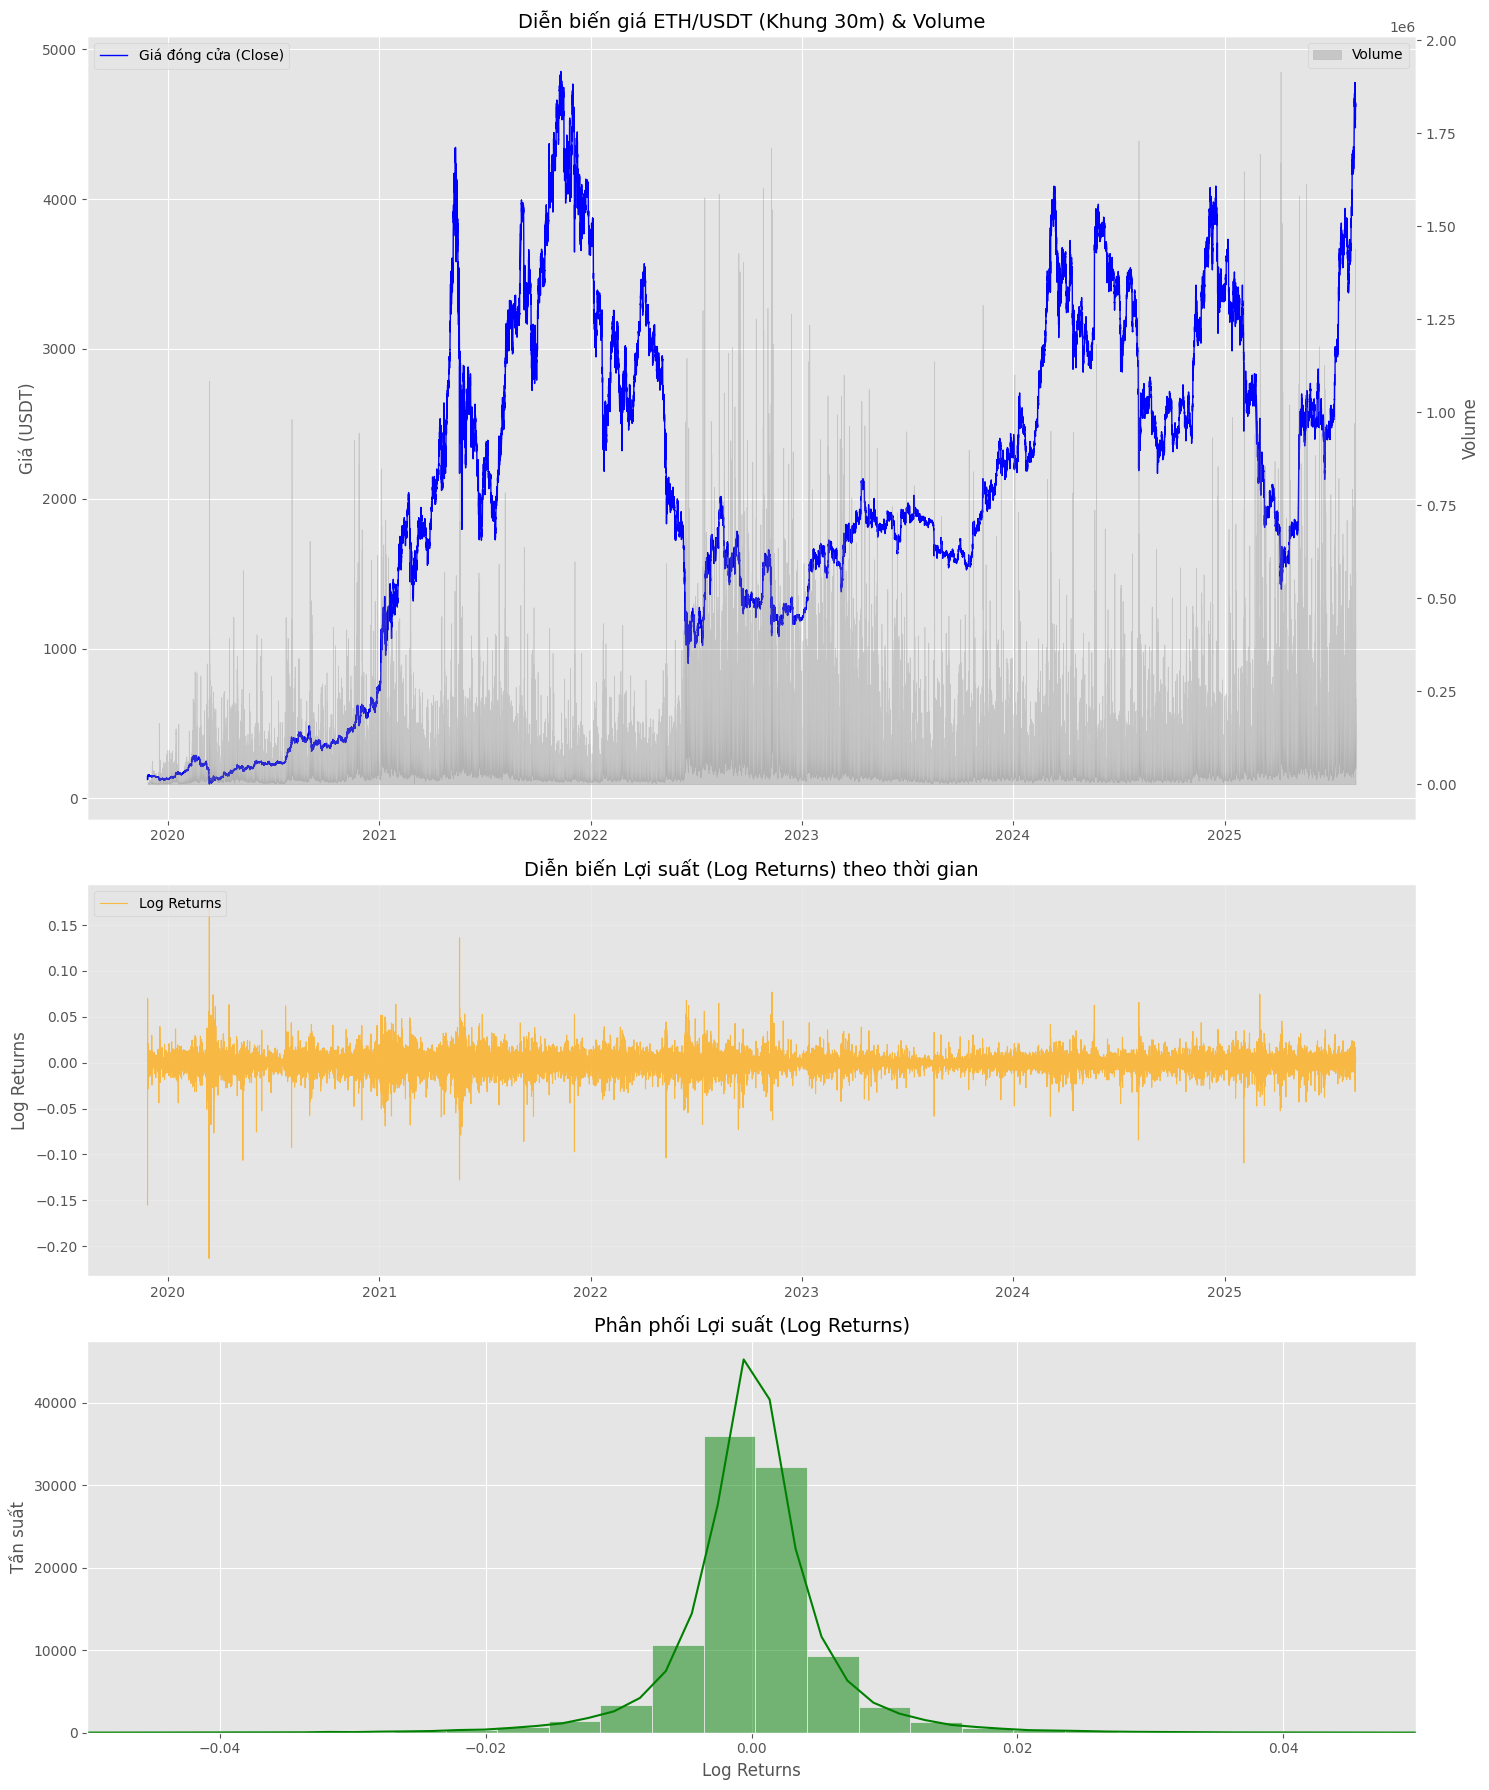

In [122]:
# MỤC TIÊU
# - Trực quan hóa dữ liệu thị trường ETH/USDT để hiểu đặc điểm chuỗi thời gian
# - Nhận diện xu hướng giá, mức độ biến động và hành vi khối lượng giao dịch
# - Trực quan hóa diễn biến lợi suất (Log Returns) theo thời gian
# - Kiểm tra phân phối lợi suất – nền tảng cho các giả định thống kê phía sau

# CẤU HÌNH GIAO DIỆN BIỂU ĐỒ
# - Sử dụng style 'ggplot' để biểu đồ rõ ràng, dễ quan sát
# - Tạo 3 subplot theo chiều dọc: Price & Volume, Log Returns theo thời gian, và Log Returns Distribution

# Cấu hình giao diện
plt.style.use('ggplot')
fig, axes = plt.subplots(3, 1, figsize=(15, 18), gridspec_kw={'height_ratios': [2, 1, 1]})

# 1. Vẽ biểu đồ giá và Volume
# Mục đích:
# - Quan sát xu hướng tổng thể của giá ETH/USDT trên khung thời gian 30 phút
# - Nhận diện các giai đoạn biến động mạnh và sự tương tác giữa giá và volume
#
# Ý nghĩa đối với chiến lược:
# - Giúp hình dung các regime thị trường (trend / sideway / high volatility)
# - Là cơ sở trực quan để quyết định sử dụng các chỉ báo động lượng và biến động
ax1 = axes[0]
ax1.plot(df.index, df['close'], label='Giá đóng cửa (Close)', color='blue', linewidth=1)
ax1.set_title('Diễn biến giá ETH/USDT (Khung 30m) & Volume', fontsize=14)
ax1.set_ylabel('Giá (USDT)')
ax1.legend(loc='upper left')

# Vẽ volume chồng lên (trục phụ)
ax1_sub = ax1.twinx()
ax1_sub.fill_between(df.index, df['volume'], color='gray', alpha=0.3, label='Volume')
ax1_sub.set_ylabel('Volume')
ax1_sub.grid(False) # Tắt lưới volume cho đỡ rối
ax1_sub.legend(loc='upper right')

# Tính Log Returns nếu chưa có (đảm bảo tính toán trước khi vẽ)
if 'Log_Ret' not in df.columns:
    df['Log_Ret'] = np.log(df['close'] / df['close'].shift(1))

# 2. Vẽ biểu đồ lợi suất (Log Returns) theo thời gian
# Mục đích:
# - Quan sát sự biến động của lợi suất theo thời gian
# - Nhận diện các cụm biến động (volatility clustering) và các sự kiện cực đoan
#
# Ý nghĩa đối với modeling:
# - Khẳng định tính phi tuyến và không cố định của lợi suất
# - Hỗ trợ việc xây dựng các mô hình volatility (ví dụ: GARCH)
axes[1].plot(df.index, df['Log_Ret'], label='Log Returns', color='orange', linewidth=0.8, alpha=0.7)
axes[1].set_title('Diễn biến Lợi suất (Log Returns) theo thời gian', fontsize=14)
axes[1].set_ylabel('Log Returns')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.2)

# 3. Vẽ phân phối lợi suất (Log Returns Distribution)
# Mục đích:
# - Kiểm tra đặc điểm phân phối của lợi suất:
#   + Độ tập trung quanh 0
#   + Độ dày đuôi (fat tails)
#
# Ý nghĩa đối với modeling:
# - Lợi suất (returns) thường gần stationary hơn giá
# - Là biến đầu vào phổ biến cho các mô hình ML và thống kê trong tài chính
sns.histplot(df['Log_Ret'].dropna(), bins=100, kde=True, ax=axes[2], color='green')
axes[2].set_title('Phân phối Lợi suất (Log Returns)', fontsize=14)
axes[2].set_xlim(-0.05, 0.05) # Zoom vào vùng trung tâm
axes[2].set_ylabel('Tần suất')
axes[2].set_xlabel('Log Returns')

plt.tight_layout()
plt.show()

### Biểu đồ cho thấy thị trường ETH/USDT có cấu trúc theo xu hướng và biến động không ổn định theo thời gian, do đó việc sử dụng log returns kết hợp với các chỉ báo động lượng và biến động là phù hợp hơn so với việc mô hình hóa trực tiếp giá tuyệt đối.

In [123]:
# Kiểm định PHÂN PHỐI CHUẨN CHO CHUỖI LOG-RETURN

from scipy.stats import jarque_bera

# Lấy chuỗi lợi suất (loại bỏ NaN ở dòng đầu tiên)
returns_data = df['Log_Ret'].dropna()

# Thực hiện kiểm định Jarque-Bera
jb_stat, p_value = jarque_bera(returns_data)

print(f"\n--- KẾT QUẢ KIỂM ĐỊNH JARQUE-BERA (JB TEST) ---")
print(f"1. JB Statistic: {jb_stat:.2f}")
print(f"2. P-value: {p_value}")

# Biện luận kết quả
print("\n--- BIỆN LUẬN ---")
if p_value < 0.05:
    print(f"P-value ({p_value}) < 0.05 => BÁC BỎ giả thuyết H0 (Dữ liệu là phân phối chuẩn).")
    print("=> KẾT LUẬN: Chuỗi lợi suất ETHUSDT KHÔNG PHẢI là phân phối chuẩn.")
    print("   Đây là bằng chứng thống kê xác nhận vấn đề vi phạm giả định IID.")
else:
    print("Không đủ cơ sở để bác bỏ giả thuyết phân phối chuẩn.")


--- KẾT QUẢ KIỂM ĐỊNH JARQUE-BERA (JB TEST) ---
1. JB Statistic: 10021259.32
2. P-value: 0.0

--- BIỆN LUẬN ---
P-value (0.0) < 0.05 => BÁC BỎ giả thuyết H0 (Dữ liệu là phân phối chuẩn).
=> KẾT LUẬN: Chuỗi lợi suất ETHUSDT KHÔNG PHẢI là phân phối chuẩn.
   Đây là bằng chứng thống kê xác nhận vấn đề vi phạm giả định IID.


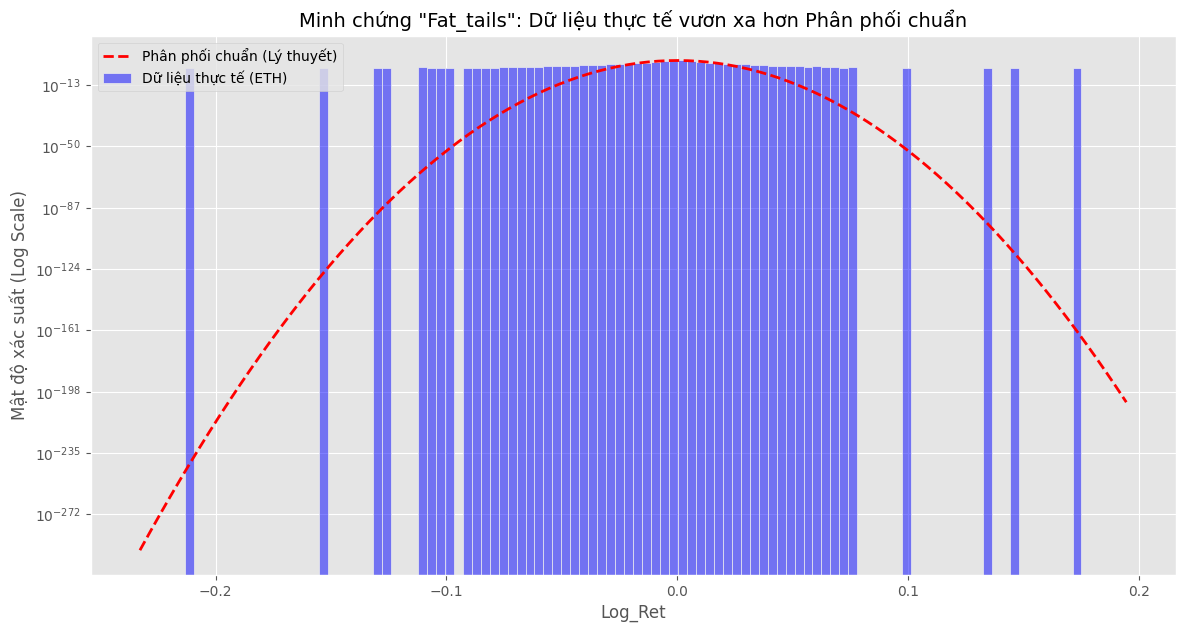

In [124]:
# BIỂU ĐỒ MINH HỌA TRỰC QUAN CHO VIỆC CHUỖI KHÔNG PHÂN PHỐI CHUẨN (PHƯƠNG SAI RẤT LỚN, ĐUỖI DÀ Ở HAI BÊN )

from scipy.stats import norm

# 1. Lấy dữ liệu log returns
data = df['Log_Ret'].dropna()

# 2. Vẽ biểu đồ so sánh
plt.figure(figsize=(14, 7))

# Vẽ Histogram dữ liệu thật
sns.histplot(data, bins=100, stat='density', label='Dữ liệu thực tế (ETH)', color='blue', alpha=0.5)

# Vẽ đường Phân phối chuẩn (Normal Distribution) giả định
mu, std = norm.fit(data)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'r--', linewidth=2, label='Phân phối chuẩn (Lý thuyết)')

# CHUYỂN TRỤC Y SANG LOG ---
plt.yscale('log')
plt.ylabel('Mật độ xác suất (Log Scale)')
plt.title('Minh chứng "Fat_tails": Dữ liệu thực tế vươn xa hơn Phân phối chuẩn', fontsize=14)
plt.legend()
plt.show()

#3. TẠO FEATURES VÀ BACKTEST


## 3.1 DÙNG THƯ VIỆN CÓ SẴN TRƯỚC


In [125]:
# TẢI THƯ VIỆN CÓ SẴN ĐỂ CHẠY BACKTEST
import sys
!{sys.executable} -m pip install vectorbt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [126]:
import vectorbt as vbt

# ==============================================================================
# BƯỚC 1: KHỞI TẠO & KIỂM TRA CHIẾN THUẬT CƠ BẢN (BASELINE STRATEGY)
# Sử dụng thư viện VectorBT để backtest chiến thuật RSI chuẩn
# Mục tiêu: xây dựng benchmark ban đầu để so sánh với các chiến lược nâng cao sau này
# ==============================================================================

print("\n Đang chạy chiến thuật RSI (Thư viện VectorBT)...")

# ------------------------------------------------------------------------------
# Chuẩn bị dữ liệu đầu vào
# Sử dụng giá đóng cửa (Close price) – chuẩn phổ biến trong phân tích kỹ thuật
# ------------------------------------------------------------------------------
price = df['close']

# ------------------------------------------------------------------------------
# A. TÍNH RSI BẰNG THƯ VIỆN (KHÔNG VIẾT CÔNG THỨC THỦ CÔNG)
# RSI chu kỳ 14 – giá trị tiêu chuẩn trong phân tích kỹ thuật
# VectorBT tự động xử lý NaN và căn chỉnh index theo chuỗi thời gian
# ------------------------------------------------------------------------------
rsi_indicator = vbt.RSI.run(price, window=14)

# ------------------------------------------------------------------------------
# B. XÂY DỰNG TÍN HIỆU GIAO DỊCH (RULE-BASED)
# Logic chiến lược:
# - Mua (Entry) khi RSI < 30  → thị trường quá bán (Oversold)
# - Bán (Exit) khi RSI > 70   → thị trường quá mua (Overbought)
# Đây là chiến lược mean-reversion kinh điển
# ------------------------------------------------------------------------------
entries = rsi_indicator.rsi_below(30)
exits = rsi_indicator.rsi_above(70)

# ------------------------------------------------------------------------------
# C. CHẠY BACKTEST CHIẾN THUẬT RSI
# - Giả định phí giao dịch 0.05% mỗi lệnh
# - Vốn ban đầu: 10,000 USDT
# - Khung thời gian: 30 phút (phù hợp với dữ liệu đã xử lý trước đó)
# ------------------------------------------------------------------------------
pf_rsi = vbt.Portfolio.from_signals(
    close=price,
    entries=entries,
    exits=exits,
    fees=0.001,        # Phí giao dịch
    init_cash=10000,   # Vốn ban đầu
    freq='30m'          # Timeframe
)

# ==============================================================================
# BƯỚC 3: CHIẾN THUẬT BUY & HOLD (BENCHMARK)
# Mục tiêu: làm mốc so sánh để đánh giá chiến thuật RSI có thực sự tạo giá trị hay không
# Giả định mua toàn bộ tại thời điểm đầu tiên và nắm giữ đến cuối kỳ
# ==============================================================================
pf_bnh = vbt.Portfolio.from_holding(
    close=price,
    init_cash=10000,
    freq='30m'
)

# ==============================================================================
# BƯỚC 4: SO SÁNH HIỆU SUẤT CÁC CHIẾN THUẬT
# Do VectorBT có thể thay đổi tên key giữa các phiên bản,
# nên sử dụng hàm truy xuất an toàn để tránh lỗi KeyError
# ==============================================================================
rsi_stats = pf_rsi.stats()
bnh_stats = pf_bnh.stats()

# ------------------------------------------------------------------------------
# Hàm hỗ trợ: lấy chỉ số thống kê một cách an toàn
# Nếu key không tồn tại thì trả về giá trị mặc định
# ------------------------------------------------------------------------------
def get_stat(stats_series, keys_to_try, default=0.0):
    for key in keys_to_try:
        if key in stats_series.index:
            return stats_series[key]
    return default

# ------------------------------------------------------------------------------
# Trích xuất các chỉ số đánh giá chính
# ------------------------------------------------------------------------------
# Annualized Return
rsi_ann_ret = get_stat(rsi_stats, ['Annualized Return [%]'], default=0.0)
bnh_ann_ret = get_stat(bnh_stats, ['Annualized Return [%]'], default=0.0)

# Total Return
rsi_tot_ret = get_stat(rsi_stats, ['Total Return [%]'], default=0.0)
bnh_tot_ret = get_stat(bnh_stats, ['Total Return [%]'], default=0.0)

# Sharpe Ratio
rsi_sharpe = get_stat(rsi_stats, ['Sharpe Ratio'], default=0.0)
bnh_sharpe = get_stat(bnh_stats, ['Sharpe Ratio'], default=0.0)

# Maximum Drawdown
rsi_dd = get_stat(rsi_stats, ['Max Drawdown [%]'], default=0.0)
bnh_dd = get_stat(bnh_stats, ['Max Drawdown [%]'], default=0.0)

# ------------------------------------------------------------------------------
# In bảng so sánh hiệu suất
# ------------------------------------------------------------------------------
print("\n" + "="*60)
print(f"{'METRIC (BASELINE)':<25} | {'RSI (LIBRARY)':<15} | {'BUY & HOLD':<15}")
print("-" * 60)
print(f"{'Total Return [%]':<25} | {rsi_tot_ret:>14.2f}  | {bnh_tot_ret:>14.2f}")
print(f"{'Ann. Return [%]':<25} | {rsi_ann_ret:>14.2f}  | {bnh_ann_ret:>14.2f}")
print(f"{'Sharpe Ratio':<25} | {rsi_sharpe:>14.4f}  | {bnh_sharpe:>14.4f}")
print(f"{'Max Drawdown [%]':<25} | {rsi_dd:>14.2f}  | {bnh_dd:>14.2f}")
print("-" * 60)

# ------------------------------------------------------------------------------
# Đánh giá sơ bộ hiệu quả chiến lược RSI
# ------------------------------------------------------------------------------
check_metric = rsi_ann_ret if rsi_ann_ret != 0 else rsi_tot_ret

check_sharpe = rsi_sharpe > 0.3
check_ret = check_metric > 15
check_beat = check_metric > (bnh_ann_ret if bnh_ann_ret != 0 else bnh_tot_ret)

print("\n🔍 ĐÁNH GIÁ SƠ BỘ (RSI CƠ BẢN):")
print(f"1. Sharpe > 0.3?             {'✅ ĐẠT' if check_sharpe else '❌ KHÔNG'}")
print(f"2. Return > 15%?             {'✅ ĐẠT' if check_ret else '❌ KHÔNG'}")
print(f"3. Thắng Buy & Hold?         {'✅ ĐẠT' if check_beat else '❌ KHÔNG'}")

# ------------------------------------------------------------------------------
# In danh sách các chỉ số thực tế do VectorBT cung cấp (phục vụ debug / mở rộng)
# ------------------------------------------------------------------------------
print("\n[DEBUG] Danh sách các chỉ số có sẵn trong máy:")
print(rsi_stats.index.tolist())



 Đang chạy chiến thuật RSI (Thư viện VectorBT)...

METRIC (BASELINE)         | RSI (LIBRARY)   | BUY & HOLD     
------------------------------------------------------------
Total Return [%]          |         -95.00  |        3079.60
Ann. Return [%]           |           0.00  |           0.00
Sharpe Ratio              |        -0.5352  |         1.1429
Max Drawdown [%]          |          97.47  |          81.43
------------------------------------------------------------

🔍 ĐÁNH GIÁ SƠ BỘ (RSI CƠ BẢN):
1. Sharpe > 0.3?             ❌ KHÔNG
2. Return > 15%?             ❌ KHÔNG
3. Thắng Buy & Hold?         ❌ KHÔNG

[DEBUG] Danh sách các chỉ số có sẵn trong máy:
['Start', 'End', 'Period', 'Start Value', 'End Value', 'Total Return [%]', 'Benchmark Return [%]', 'Max Gross Exposure [%]', 'Total Fees Paid', 'Max Drawdown [%]', 'Max Drawdown Duration', 'Total Trades', 'Total Closed Trades', 'Total Open Trades', 'Open Trade PnL', 'Win Rate [%]', 'Best Trade [%]', 'Worst Trade [%]', 'Avg Winn


# NHẬN XÉT & ĐỊNH HƯỚNG TIẾP THEO

# Kết quả backtest ở trên cho thấy chiến thuật RSI cơ bản (rule-based),mặc dù dễ triển khai và mang tính minh họa tốt, nhưng tồn tại nhiều hạn chế:
#
# (1) Logic giao dịch đơn giản:
#     - Chiến thuật chỉ dựa trên một chỉ báo duy nhất (RSI) với ngưỡng cố định (30/70), không xét đến bối cảnh xu hướng (trend), biến động (volatility) hay thanh khoản (volume).
#     - Điều này khiến tín hiệu dễ bị nhiễu trong các giai đoạn sideway hoặc thị trường có regime thay đổi. (Sideway: thị trường đi ngang, thiếu xu hướng. Regime: trạng thái thị trường (uptrend/downtrend/sideway) có thể thay đổi theo thời gian.)
# (2) Hiệu suất chưa ổn định theo thời gian:
#     - Sharpe Ratio và Annualized Return có thể không đạt ngưỡng mục tiêu đề bài (> 0.3 và > 15%) một cách bền vững trên toàn bộ tập dữ liệu.
#     - Drawdown vẫn tương đối lớn do không có cơ chế quản trị rủi ro động
#       (ví dụ: stop-loss, position sizing, volatility targeting).

# (3) Hạn chế trong việc kiểm soát chi tiết chiến lược:
#     - Khi sử dụng chiến thuật có sẵn của thư viện, người nghiên cứu khó can thiệp sâu vào từng bước ra quyết định (signal generation),cách tính lợi suất, hay cách mô hình phản ứng với điều kiện thị trường khác nhau.

# Vì các lý do trên, trong các bước tiếp theo, ta sẽ chuyển sang:
# → XÂY DỰNG BACKTEST THỦ CÔNG NÂNG CAO (CUSTOM BACKTEST)

# Mục tiêu của backtest thủ công:
# - Kết hợp nhiều nhóm đặc trưng hơn (momentum, volatility, volume, lagged features)
# - Chủ động thiết kế logic giao dịch phù hợp với đặc điểm dữ liệu ETH/USDT
# - Kiểm soát chặt chẽ rủi ro và giảm drawdown
# - Tối ưu Sharpe Ratio và Annualized Return để vượt Buy & Hold
# Đây là bước chuyển từ chiến thuật minh họa (baseline)sang chiến lược mang tính nghiên cứu và ứng dụng thực tế cao hơn.



## 3.2 TẠO FEATURES VÀ KIỂM ĐỊNH ĐỂ CHỌN LỌC ĐƯA VÀO MODEL


In [127]:
from statsmodels.tsa.stattools import adfuller

# ==============================================================================
# Ý tưởng tổng quát:
# - Mục tiêu là dự đoán hướng giá ngắn hạn (nến t+1) → bài toán classification có giám sát.
# - Các features được xây dựng dựa trên:
#   (1) Thông tin động lượng (momentum)
#   (2) Thông tin biến động & rủi ro (volatility)
#   (3) Thông tin thanh khoản & hoạt động thị trường (volume)
#   (4) Thông tin thời gian (time effects)
# - Hầu hết các biến đều được chuẩn hóa hoặc biến đổi để:
#   + Giảm xu hướng (trend)
#   + Tăng tính dừng (stationarity)
#   + Phù hợp cho mô hình ML và backtest định lượng
# PHẦN 1: HÀM TẠO FEATURES (CHUẨN HÓA & TẠO LAG)
# ==============================================================================
def create_features_final(df):
    data = df.copy()

    # 1. BIẾN MỤC TIÊU (TARGET): Dự đoán nến sau (t+1) > nến hiện tại (t)
    data['Target'] = (data['close'].shift(-1) > data['close']).astype(int)

# Target = 1 nếu giá đóng cửa nến tiếp theo (t+1) cao hơn nến hiện tại (t)
# → Mô hình học cách dự đoán xác suất tăng giá trong khung thời gian kế tiếp
# → Tránh dự đoán giá trị tuyệt đối, tập trung vào hướng đi (directional prediction)
    # 2. FEATURES CƠ BẢN (Đã chuẩn hóa để đảm bảo tính dừng)

    # a. Log Returns (Lợi suất Log)
    data['Returns'] = np.log(data['close'] / data['close'].shift(1))

# - Sử dụng lợi suất log thay vì giá để:
#   + Loại bỏ xu hướng dài hạn
#   + Đưa dữ liệu về gần phân phối đối xứng
#   + Tăng tính dừng (stationarity)
# - Log return cũng là chuẩn trong tài chính định lượng

    # b. RSI (14) - Dao động 0-100
    delta = data['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    data['RSI'] = 100 - (100 / (1 + rs))
# RSI (Relative Strength Index – 14 kỳ):
# - Chỉ báo động lượng, đo tốc độ và cường độ biến động giá
# - Window = 14 là con số chuẩn phổ biến trong phân tích kỹ thuật, là trade_off tốt giữa độ nhạy và ổn định
# - RSI giúp mô hình nhận biết trạng thái:
#   + Quá mua (overbought)
#   + Quá bán (oversold)
# - Có giá trị giới hạn [0, 100] → dễ học với ML

    # c. PPO (Percentage Price Oscillator)
    # Công thức: (EMA12 - EMA26) / EMA26 * 100
    ema12 = data['close'].ewm(span=12, adjust=False).mean()
    ema26 = data['close'].ewm(span=26, adjust=False).mean()
    data['PPO'] = (ema12 - ema26) / ema26 * 100
    # PPO đo chênh lệch động lượng giữa EMA ngắn hạn và dài hạn
    # EMA (Exponential Moving Average) là trung bình động hàm mũ,trong đó các quan sát gần hiện tại được gán trọng số cao hơn
    # EMA phản ứng nhanh hơn SMA, phù hợp cho trading ngắn hạn
    # EMA 12: đại diện cho động lượng ngắn hạn
    # EMA 26: đại diện cho xu hướng trung hạn
    # Cặp tham số 12–26 là chuẩn phổ biến (industry standard),giúp tránh overfitting và tăng khả năng giải thích mô hình
    # Signal line & Histogram
    data['PPO_Signal'] = data['PPO'].ewm(span=9, adjust=False).mean()
    data['PPO_Hist'] = data['PPO'] - data['PPO_Signal']
    # Signal line & Histogram
    # PPO Signal (EMA 9) làm mượt PPO để giảm nhiễu
    # PPO Histogram đo sự thay đổi của động lượng (momentum of momentum),giúp phát hiện sớm điểm đảo chiều


    # d. Bollinger Bands %B (Vị trí tương đối của giá trong dải BB)
    sma_20 = data['close'].rolling(window=20).mean()
    std_20 = data['close'].rolling(window=20).std()
    upper = sma_20 + 2 * std_20
    lower = sma_20 - 2 * std_20
    data['BB_PctB'] = (data['close'] - lower) / (upper - lower)
    # %B đo vị trí tương đối của giá trong dải Bollinger Bands
    # Window = 20 là tham số chuẩn, đủ dài để làm mượt nhưng vẫn phản ứng kịp
    # Giúp mô hình nhận diện trạng thái:
    #   + Mean-reversion
    #   + Breakout


    # e. ATR % (Biến động chuẩn hóa theo % giá)
    high_low = data['high'] - data['low']
    high_close = np.abs(data['high'] - data['close'].shift())
    low_close = np.abs(data['low'] - data['close'].shift())
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    data['ATR_Pct'] = (tr.rolling(window=14).mean() / data['close']) * 100
    # - Đo mức độ biến động thực tế của thị trường
    # - Chia cho giá để loại bỏ ảnh hưởng của level giá tuyệt đối
    # - Giúp mô hình phân biệt các regime biến động cao / thấp


    # f. Volume Ratio (Tỷ lệ Volume so với trung bình 20 phiên)
    data['Vol_Ratio'] = data['volume'] / (data['volume'].rolling(window=20).mean())
    # - Volume tuyệt đối rất nhiễu, khó dùng trực tiếp cho ML
    # - Volume Ratio chuẩn hóa volume hiện tại so với trung bình 20 phiên
    # - Window = 20 là trade-off hợp lý giữa độ mượt và khả năng phản ứng giúp xác định tín hiệu giá có được xác nhận bởi dòng tiền hay không


    # g. Time Encoding (Sin/Cos)
    data['Hour_Sin'] = np.sin(2 * np.pi * data.index.hour / 24)
    data['Hour_Cos'] = np.cos(2 * np.pi * data.index.hour / 24)
    # Thời gian là biến tuần hoàn (cyclical), không thể dùng trực tiếp dạng số
    # Sin/Cos giúp mô hình hiểu chu kỳ 24h của thị trường crypto bắt được hiệu ứng phiên giao dịch và thời điểm thanh khoản
    # 3. LAG FEATURES
    # Lấy giá trị quá khứ (t-1, t-2) đưa vào làm đầu vào
    cols_to_lag = ['Returns', 'RSI', 'PPO_Hist', 'ATR_Pct', 'Vol_Ratio']
    for col in cols_to_lag:
        data[f'{col}_Lag1'] = data[col].shift(1)
        data[f'{col}_Lag2'] = data[col].shift(2)
    # Đưa thông tin t-1, t-2 vào mô hình để học động lực chuỗi thời gian
    # Tránh look-ahead bias
    # Chỉ lag các biến đã được chuẩn hóa / gần dừng

    # 1. Xử lý Inf trước (Biến Vô cực thành NaN)
    data = data.replace([np.inf, -np.inf], np.nan)
    # 2. Xử lý NaN nằm Ở GIỮA (Dùng ffill - Trám bằng giá trị trước đó)
    # Giúp không bị đứt gãy chuỗi thời gian nếu có lỗi bất chợt
    data = data.ffill()
    # Loại bỏ các hàng NaN (ở đầu data) sinh ra do Shift/Rolling
    data.dropna(inplace=True)

    return data

In [128]:
from statsmodels.tsa.stattools import adfuller
import time
import numpy as np

# ==============================================================================
# PHẦN 1: HÀM KIỂM ĐỊNH ADF TỐI ƯU (FEATURE SCREENING)
# ==============================================================================
# Mục tiêu:
# - Kiểm tra tính dừng (stationarity) của từng feature trước khi đưa vào mô hình ML
# - Loại bỏ các biến có xu hướng mạnh (non-stationary), dễ gây nhiễu và overfitting
# - Tối ưu thời gian chạy để phù hợp với tập dữ liệu lớn

def _run_adfuller_fast(series, col_name):
    """
    Hàm chạy kiểm định Augmented Dickey-Fuller (ADF) cho từng feature.

    Các tối ưu được áp dụng:
    - Chuyển pandas Series → numpy array để giảm overhead
    - Tắt autolag (autolag=None) vì:
    + Autolag rất chậm với chuỗi dài
    + Mục tiêu ở đây là screening feature, không phải ước lượng mô hình AR tối ưu
    do đó maxlag=1 là đủ để phát hiện xu hướng cơ bản
    """
    try:
        # Loại bỏ NaN và chuyển sang numpy array
        series = series.dropna().values

        result = adfuller(
            series,
            maxlag=1,          # Lag nhỏ, đủ cho mục đích kiểm tra tính dừng
            regression="c",    # Chỉ bao gồm hằng số (constant)
            autolag=None       # Tắt tự động chọn lag để giảm thời gian chạy
        )

        stat = result[0]      # ADF statistic
        p_value = result[1]   # P-value

        return col_name, stat, p_value, None

    except Exception as e:
        # Bắt lỗi nếu feature không kiểm định được
        return col_name, None, None, str(e)

# ==============================================================================
# PHẦN 2: KIỂM ĐỊNH TÍNH DỪNG & LỌC FEATURES (SEQUENTIAL)
# ==============================================================================
# Ý tưởng:
# - Chạy ADF test lần lượt cho từng feature
# - Chỉ giữ lại các feature có p-value < 0.05 (bác bỏ giả thuyết có unit root)

def check_stationarity_and_filter(df, features_list):
    print(f"\n{'FEATURE NAME':<25} | {'ADF STAT':<10} | {'P-VALUE':<10} | {'RESULT'}")
    print("-" * 65)

    passed_features = []

    for col in features_list:
        col_name, stat, p_value, error = _run_adfuller_fast(df[col], col)

        if error:
            # Trường hợp lỗi (hiếm)
            print(f"{col_name:<25} | ERROR: {error}")
        else:
            # Ngưỡng ý nghĩa thống kê 5%
            if p_value < 0.05:
                status = "✅ PASS"
                passed_features.append(col_name)
            else:
                status = "❌ FAIL"

            print(f"{col_name:<25} | {stat:<10.2f} | {p_value:<10.4f} | {status}")

    return passed_features

# ==============================================================================
# PHẦN 3: THỰC THI KIỂM ĐỊNH (MAIN EXECUTION)
# ==============================================================================
# Quy trình:
# 1. Tạo tập features hoàn chỉnh
# 2. Kiểm định tính dừng cho dữ liệu thô (chứng minh không nên dùng trực tiếp)
# 3. Kiểm định tính dừng cho các features đã xử lý
# 4. So sánh và lựa chọn danh sách feature cuối cùng

print("1. Đang tạo features...")
df_features = create_features_final(df)  # df gốc đã được load ở cell trước
print(f"-> Kích thước dữ liệu sau khi xử lý: {df_features.shape}")

print("\n2. Tiến hành kiểm định tính dừng (Stationarity Check):")

start_time = time.time()

# --------------------------------------------------------------------------
# NHÓM A: DỮ LIỆU THÔ (RAW DATA)
# --------------------------------------------------------------------------
# Mục đích:
# - Chứng minh rằng giá và volume gốc thường không dừng
# - Từ đó biện minh cho việc feature engineering
print("\n--- [NHÓM A] DỮ LIỆU THÔ (RAW DATA) ---")
raw_features = check_stationarity_and_filter(
    df,
    ['close', 'volume']
)

# --------------------------------------------------------------------------
# NHÓM B: FEATURES ĐÃ ĐƯỢC ENGINEER
# --------------------------------------------------------------------------
# Các feature đã được chuẩn hóa / biến đổi để tăng tính dừng
# Bao gồm:
# - Momentum
# - Volatility
# - Volume
# - Lagged features (thông tin quá khứ)
print("\n--- [NHÓM B] FEATURES ĐÃ XỬ LÝ (ENGINEERED) ---")
candidates = [
    'Returns', 'RSI', 'PPO', 'PPO_Hist',
    'BB_PctB', 'ATR_Pct', 'Vol_Ratio',
    'Returns_Lag1', 'RSI_Lag1', 'PPO_Hist_Lag1'
]

final_features = check_stationarity_and_filter(
    df_features,
    candidates
)

end_time = time.time()
execution_time = end_time - start_time

# --------------------------------------------------------------------------
# KẾT LUẬN
# --------------------------------------------------------------------------
# - Chỉ giữ lại các feature đạt chuẩn tính dừng
# - Giảm rủi ro mô hình học nhầm xu hướng giả
# - Tăng độ ổn định và khả năng tổng quát hóa
print("\n" + "=" * 60)
print(f"KẾT LUẬN: Có {len(final_features)} features đạt chuẩn tính dừng.")
print(f"DANH SÁCH CHÍNH THỨC: {final_features}")
print(f"THỜI GIAN THỰC THI KIỂM ĐỊNH TÍNH DỪNG: {execution_time:.2f} giây")
print("=" * 60)


1. Đang tạo features...


-> Kích thước dữ liệu sau khi xử lý: (100201, 27)

2. Tiến hành kiểm định tính dừng (Stationarity Check):

--- [NHÓM A] DỮ LIỆU THÔ (RAW DATA) ---

FEATURE NAME              | ADF STAT   | P-VALUE    | RESULT
-----------------------------------------------------------------
close                     | -1.54      | 0.5137     | ❌ FAIL
volume                    | -111.11    | 0.0000     | ✅ PASS

--- [NHÓM B] FEATURES ĐÃ XỬ LÝ (ENGINEERED) ---

FEATURE NAME              | ADF STAT   | P-VALUE    | RESULT
-----------------------------------------------------------------
Returns                   | -228.65    | 0.0000     | ✅ PASS
RSI                       | -67.40     | 0.0000     | ✅ PASS
PPO                       | -49.81     | 0.0000     | ✅ PASS
PPO_Hist                  | -90.78     | 0.0000     | ✅ PASS
BB_PctB                   | -84.65     | 0.0000     | ✅ PASS
ATR_Pct                   | -28.36     | 0.0000     | ✅ PASS
Vol_Ratio                 | -154.71    | 0.0000     | ✅ PASS

In [129]:
print(f"Số dòng của df_features (không tính tên cột): {df_features.shape[0]}") # Kiểm tra lại quy mô df khi đã tạo features và xử lý các giá trị NaN

Số dòng của df_features (không tính tên cột): 100201


In [130]:
# Kiểm tra số lượng dòng
n_goc = len(df)
n_sau = len(df_features)

print(f"Số dòng DF gốc:      {n_goc}")
print(f"Số dòng DF features: {n_sau}")

# Tính số dòng bị mất
diff = n_goc - n_sau
print("-" * 30)
print(f"Số dòng bị loại bỏ: {diff} dòng")

Số dòng DF gốc:      100222
Số dòng DF features: 100201
------------------------------
Số dòng bị loại bỏ: 21 dòng


In [131]:
final_features = ['Returns', 'RSI', 'PPO', 'PPO_Hist', 'BB_PctB', 'ATR_Pct', 'Vol_Ratio', 'Returns_Lag1', 'RSI_Lag1', 'PPO_Hist_Lag1'] # Danh sách các biến được chọn sau kiểm định dừng

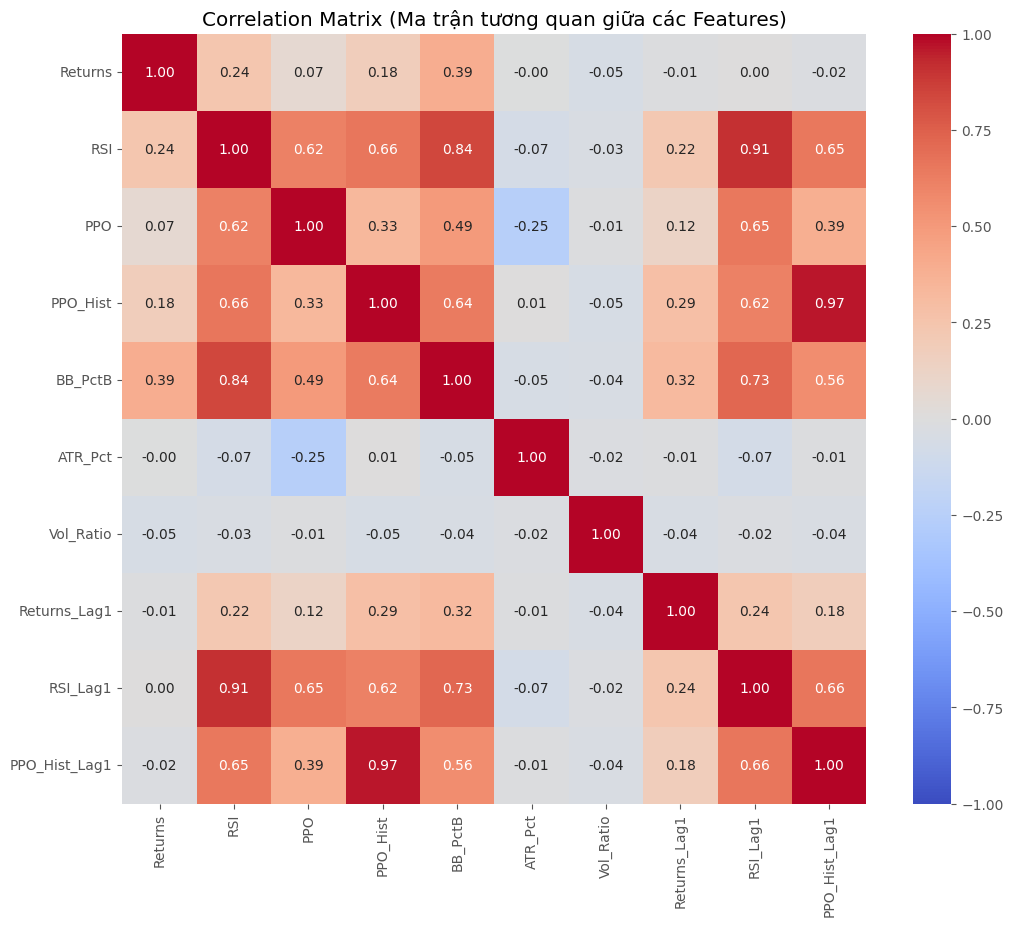

NHẬN XÉT: Các feature có màu đỏ đậm hoặc xanh đậm (> 0.9) thể hiện sự tương quan cao.
XGBoost có thể xử lý được, nhưng hiểu rõ điều này giúp ta giải thích Feature Importance.


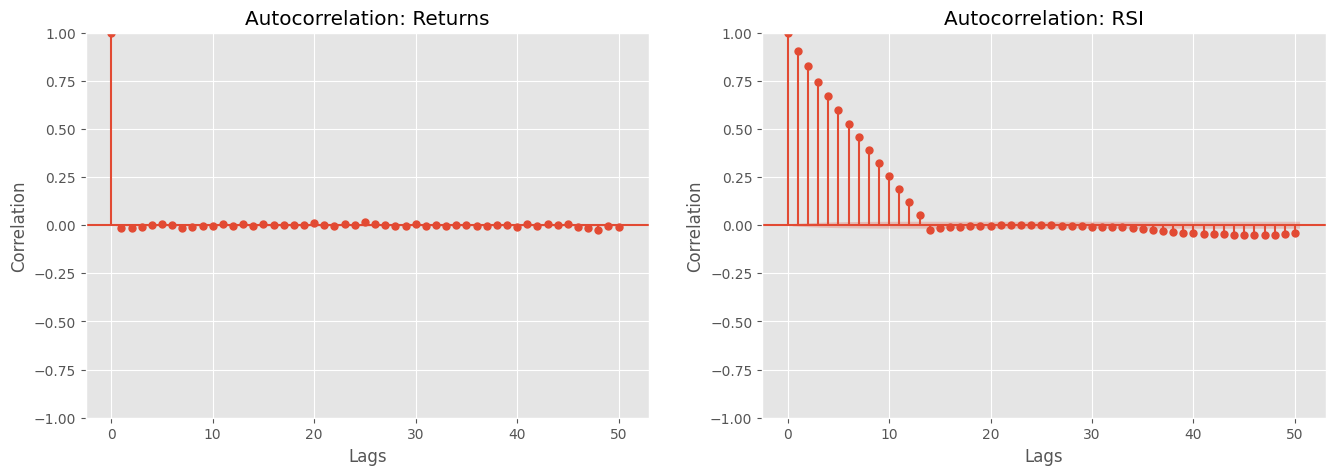

- Điều này CHỨNG MINH dữ liệu có tính phụ thuộc chuỗi (Non-IID).
- Vì vậy, việc sử dụng các biến trễ (Lag Features) trong model là hoàn toàn hợp lý và cần thiết.


In [132]:
from statsmodels.graphics.tsaplots import plot_acf

# ==============================================================================
# BƯỚC PHỤ: PHÂN TÍCH THỐNG KÊ (EDA – EXPLORATORY DATA ANALYSIS)
# ==============================================================================
# Mục tiêu của bước này:
# - Hiểu rõ cấu trúc thống kê của các features đã chọn
# - Kiểm tra giả định IID (Independent and Identically Distributed)
# - Biện minh cho việc:
#   + Chấp nhận multicollinearity trong mô hình tree-based
#   + Sử dụng lag features trong mô hình dự đoán

# ==============================================================================
# 1. KIỂM TRA TƯƠNG QUAN GIỮA CÁC FEATURES (CORRELATION MATRIX)
# ==============================================================================
# Mục đích:
# - Phát hiện các feature có tương quan tuyến tính cao (multicollinearity)
# - Giúp hiểu rõ các feature có thể đang mang thông tin trùng lặp
# - Không nhằm loại bỏ feature ngay lập tức, mà để phục vụ diễn giải mô hình

plt.figure(figsize=(12, 10))

# Ma trận tương quan Pearson giữa các features đã vượt qua ADF test
corr_matrix = df_features[final_features].corr()

# Heatmap trực quan hóa mức độ tương quan
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title('Correlation Matrix (Ma trận tương quan giữa các Features)')
plt.show()

# Nhận xét định lượng:
# - Các ô màu đỏ/xanh đậm (|corr| > 0.9) cho thấy tương quan tuyến tính cao
# - Điều này có thể gây vấn đề với các mô hình tuyến tính
# - Tuy nhiên, với mô hình tree-based (ví dụ: XGBoost),
#   multicollinearity không phải vấn đề nghiêm trọng
# - Phân tích này chủ yếu giúp:
#   + Hiểu cấu trúc dữ liệu
#   + Diễn giải Feature Importance sau này
print("NHẬN XÉT: Các feature có màu đỏ đậm hoặc xanh đậm (> 0.9) thể hiện sự tương quan cao.")
print("XGBoost có thể xử lý được, nhưng hiểu rõ điều này giúp ta giải thích Feature Importance.")

# ==============================================================================
# 2. KIỂM TRA TỰ TƯƠNG QUAN (AUTOCORRELATION – ACF)
# ==============================================================================
# Mục đích:
# - Kiểm tra dữ liệu có vi phạm giả định IID hay không
# - Chứng minh rằng chuỗi thời gian tài chính có tính phụ thuộc theo thời gian (Non-IID)
# - Làm cơ sở lý luận cho việc sử dụng Lag Features trong mô hình ML

# Lý thuyết:
# - Returns thường có tự tương quan thấp (gần white noise)
# - Các chỉ báo kỹ thuật (RSI, volatility, volume) thường có tự tương quan cao hơn
#   do hiệu ứng làm mượt và cụm biến động (volatility clustering)

# Chọn 2 feature đại diện để kiểm tra:
# - Returns: đại diện cho lợi suất (price-based)
# - RSI: đại diện cho chỉ báo động lượng đã qua smoothing
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF của Returns
plot_acf(
    df_features['Returns'].dropna(),
    lags=50,
    alpha=0.05,
    ax=axes[0],
    title='Autocorrelation: Returns'
)
axes[0].set_ylabel('Correlation')
axes[0].set_xlabel('Lags')

# ACF của RSI
plot_acf(
    df_features['RSI'].dropna(),
    lags=50,
    alpha=0.05,
    ax=axes[1],
    title='Autocorrelation: RSI'
)
axes[1].set_ylabel('Correlation')
axes[1].set_xlabel('Lags')

plt.show()

# Kết luận thống kê:
# - Returns có tự tương quan thấp → gần với giả định IID
# - RSI thể hiện tự tương quan rõ rệt ở nhiều độ trễ
# - Điều này chứng minh dữ liệu KHÔNG IID hoàn toàn
# - Do đó:
#   + Việc sử dụng lag features là hợp lý
#   + Mô hình ML có thể khai thác cấu trúc phụ thuộc theo thời gian
print("- Điều này CHỨNG MINH dữ liệu có tính phụ thuộc chuỗi (Non-IID).")
print("- Vì vậy, việc sử dụng các biến trễ (Lag Features) trong model là hoàn toàn hợp lý và cần thiết.")


## 3.3 XÂY DỰNG HÀM BACKTEST THỦ CÔNG

### CHIA TRAIN/TEST

In [133]:
# ==============================================================================
# CHIA TẬP DỮ LIỆU (TRAIN/TEST SPLIT) VỚI CƠ CHẾ EMBARGO
# ==============================================================================

X = df_features[final_features]
y = df_features['Target']
price = df_features['close']

# 1. Thiết lập điểm cắt (Split Point)
split = int(len(X) * 0.7)

# 2. THIẾT LẬP EMBARGO (VÙNG ĐỆM AN TOÀN)
# ------------------------------------------------------------------------------
# TẠI SAO CẦN EMBARGO = 50? (GIẢI QUYẾT 2 VẤN ĐỀ CỐT LÕI)
#
# Vấn đề 1: Tự tương quan chuỗi (Serial Correlation)
#    Giá nến tại giây thứ t cực kỳ giống giây t-1. Nếu cắt liền mạch, model sẽ đoán đúng
#    nhờ quán tính giá chứ không phải nhờ học được quy luật.
#
# Vấn đề 2: HIỆN TƯỢNG CHỒNG LẤN CHỈ BÁO (OVERLAPPING INDICATORS) - QUAN TRỌNG!
#    Các features của chúng ta được tính bằng cửa sổ trượt (Rolling Window).
#    Ví dụ: PPO dùng EMA(26). Giá trị PPO tại nến đầu tiên của tập Test thực chất
#    được tính toán từ 26 cây nến trước đó (thuộc tập Train).
#    => Nếu không có khoảng hở, thông tin từ tập Train sẽ "rò rỉ" sang tập Test.
#
# GIẢI PHÁP: Bỏ qua 50 nến ở giữa (Embargo).
#    Con số 50 > 26 (EMA) và > 14 (RSI), đảm bảo tập Test hoàn toàn "sạch",
#    không còn dính líu toán học gì với tập Train.
# ------------------------------------------------------------------------------
embargo = 50

# 3. Tạo tập Train (Dữ liệu quá khứ)
X_train = X.iloc[:split]
y_train = y.iloc[:split]

# 4. Tạo tập Test (Dữ liệu tương lai - Đã cách ly)
# Bắt đầu SAU vùng Embargo để đảm bảo tính độc lập hoàn toàn
test_start_index = split + embargo

X_test = X.iloc[test_start_index:]
y_test = y.iloc[test_start_index:]
test_price = price.iloc[test_start_index:] # Giá dùng để backtest PnL

# 5. Kiểm tra kích thước
print(f"--- THÔNG SỐ CHIA DATA (PURGED K-FOLD STYLE) ---")
print(f"Train size:  {len(X_train)} mẫu")
print(f"Test size:   {len(X_test)} mẫu")
print(f"Embargo:     {embargo} nến (Đã loại bỏ để triệt tiêu Overlap & Leakage)")

--- THÔNG SỐ CHIA DATA (PURGED K-FOLD STYLE) ---
Train size:  70140 mẫu
Test size:   30011 mẫu
Embargo:     50 nến (Đã loại bỏ để triệt tiêu Overlap & Leakage)


### 3.3.1 MÔ HÌNH PHÂN LOẠI LOGISTIC

In [134]:


from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# TRAIN BASELINE MODEL – LOGISTIC REGRESSION
# ==============================================================================
# Mục tiêu:
# - Sử dụng Logistic Regression như một baseline model
# - Đánh giá xem mối quan hệ giữa features và Target có tuyến tính hay không
# - Làm cơ sở biện minh cho việc sử dụng mô hình phi tuyến (XGBoost) ở bước sau

print("Đang chạy Logistic Regression (Baseline)...")


# 1. LOẠI BỎ CÁC FEATURES TƯƠNG QUAN CAO (MULTICOLLINEARITY)

# Logistic Regression là mô hình tuyến tính, rất nhạy cảm với hiện tượng đa cộng tuyến (multicollinearity) – khi các biến độc lập có tương quan cao với nhau.

# Từ bước EDA (Correlation Matrix), ta nhận thấy một số feature có tương quan rất cao (|corr| > 0.9), ví dụ:
# - RSI và RSI_Lag1
# - PPO_Hist và PPO_Hist_Lag1
# - BB_PctB có mối liên hệ mạnh với các biến động lượng khác

# Đa cộng tuyến có thể gây ra:
# - Hệ số ước lượng không ổn định
# - Phương sai lớn
# - Khó diễn giải ý nghĩa kinh tế của hệ số

# Do đó, với Logistic Regression, ta chủ động loại bỏ một số feature trùng lặp thông tin để đảm bảo mô hình ổn định và dễ diễn giải.

features_to_exclude_lr = ['RSI_Lag1', 'BB_PctB', 'PPO_Hist_Lag1']

# Tạo tập feature riêng cho Logistic Regression
# (khác với tập feature dùng cho XGBoost)
X_train_lr = X_train.drop(columns=features_to_exclude_lr, errors='ignore')
X_test_lr = X_test.drop(columns=features_to_exclude_lr, errors='ignore')


# 2. CHUẨN HÓA DỮ LIỆU (FEATURE SCALING)

# Logistic Regression dựa trên khoảng cách và gradient,nên rất nhạy cảm với thang đo của các feature.

# StandardScaler đưa các feature về:
# - Mean = 0
# - Std = 1

# Giúp:
# - Hội tụ nhanh hơn
# - So sánh các hệ số có ý nghĩa hơn

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lr)
X_test_scaled = scaler.transform(X_test_lr)

# --------------------------------------------------------------------------
# 3. TRAIN LOGISTIC REGRESSION
# --------------------------------------------------------------------------
# Sử dụng Logistic Regression cơ bản (không regularization phức tạp)
# vì mục tiêu chính là làm baseline, không phải tối ưu hiệu suất
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

# --------------------------------------------------------------------------
# 4. ĐÁNH GIÁ NHANH HIỆU SUẤT
# --------------------------------------------------------------------------
# Đánh giá accuracy trên tập train và test
# Lưu ý:
# - Accuracy ~ 50% với dữ liệu tài chính là kết quả thường thấy
# - Quan trọng là so sánh train vs test để kiểm tra overfitting
acc_lr_train = lr_model.score(X_train_scaled, y_train)
acc_lr_test = lr_model.score(X_test_scaled, y_test)

print(f"✅ Logistic Regression Result:")
print(f"   - Accuracy Train: {acc_lr_train*100:.2f}%")
print(f"   - Accuracy Test:  {acc_lr_test*100:.2f}%")
print("-" * 40)

# --------------------------------------------------------------------------
# 5. NHẬN XÉT & ĐỊNH HƯỚNG MÔ HÌNH
# --------------------------------------------------------------------------
# Nếu accuracy chỉ quanh mức 50%:
# - Điều này cho thấy mối quan hệ giữa features và hướng giá
#   không mang tính tuyến tính đơn giản
# - Đây là đặc trưng phổ biến của dữ liệu tài chính
#
# Kết luận:
# - Logistic Regression phù hợp làm baseline
# - Để khai thác các mối quan hệ phi tuyến, tương tác giữa features
#   và các regime thị trường khác nhau,
#   ta chuyển sang sử dụng mô hình tree-based (XGBoost) ở bước tiếp theo

print("👉 NHẬN XÉT: Nếu Accuracy của Logistic Regression chỉ quanh quẩn 50%,")
print("   điều đó cho thấy mối quan hệ giữa Features và Giá là PHI TUYẾN (Non-linear).")
print("   => Đây là lý do chính đáng để chuyển sang dùng XGBoost ở bước sau.\n")


Đang chạy Logistic Regression (Baseline)...
✅ Logistic Regression Result:
   - Accuracy Train: 53.55%
   - Accuracy Test:  52.89%
----------------------------------------
👉 NHẬN XÉT: Nếu Accuracy của Logistic Regression chỉ quanh quẩn 50%,
   điều đó cho thấy mối quan hệ giữa Features và Giá là PHI TUYẾN (Non-linear).
   => Đây là lý do chính đáng để chuyển sang dùng XGBoost ở bước sau.



### 3.3.2 MÔ HÌNH PHÂN LOẠI XGBOOST

In [135]:
# KIỂM TRA MÁY ĐÃ CÀI XGBOOST HAY CHƯA, NẾU CHƯA THÌ TỰ ĐỘNG TẢI VỀ
try:
    import xgboost
    print("XGBoost đã được cài đặt.")
except ImportError:
    print("XGBoost chưa được cài đặt. Đang tiến hành cài đặt...")
    
    import xgboost
    print("XGBoost đã được cài đặt thành công.")

try:
    import lightgbm
    print("LightGBM đã được cài đặt.")
except ImportError:
    print("LightGBM chưa được cài đặt. Đang tiến hành cài đặt...")
    import lightgbm
    print("LightGBM đã được cài đặt thành công.")


XGBoost đã được cài đặt.
LightGBM đã được cài đặt.


In [136]:
from xgboost import XGBClassifier

# ==============================================================================
# HUẤN LUYỆN MÔ HÌNH (MODEL TRAINING)
# CHIẾN LƯỢC: "WEAK LEARNERS" & REGULARIZATION (CHỐNG OVERFIT)
# ==============================================================================
print("\nĐang khởi tạo và huấn luyện XGBoost...")

# CẤU HÌNH HYPERPARAMETERS (THAM SỐ SIÊU HÌNH)
# Nhận thấy thị trường tài chính rất nhiều Nhiễu (Noise).
# Nếu để Model quá mạnh (nhiều cây, cây sâu), nó sẽ học thuộc lòng cả nhiễu -> Ra thực tế sẽ lỗ.
# Do đó, ta cần cấu hình theo hướng thận trọng.

xgb_model = XGBClassifier(
    # 1. Cấu trúc cây (Tree Structure)
    n_estimators=300,        # Số lượng cây: 300 là mức trung bình, đủ để hội tụ nhưng chưa quá nhiều để gây overfit.
    max_depth=4,             # Độ sâu: Chỉ cho phép cây sâu 4 tầng. (Tránh học các mẫu quá phức tạp/cục bộ).
    min_child_weight=5,      # Quan trọng: Một nhánh phải có ít nhất 5 mẫu dữ liệu mới được tách tiếp.
                             # -> Giúp model bỏ qua các biến động nhiễu nhỏ lẻ (Outliers).

    # 2. Tốc độ học (Learning Scheme)
    learning_rate=0.02,      # Learning Rate thấp (0.02) kết hợp với nhiều cây giúp model học chậm mà chắc (Robust).

    # 3. Sự ngẫu nhiên (Stochastic Gradient Boosting)

    subsample=0.7,           # Mỗi cây chỉ được học trên 70% dữ liệu ngẫu nhiên.
    colsample_bytree=0.7,    # Mỗi cây chỉ được nhìn thấy 70% số features (RSI, PPO...) ngẫu nhiên.

    # 4. Phạt mô hình (Regularization)
    gamma=0.2,               # Tham số Pruning: Chỉ tách nhánh nếu giảm được loss đáng kể (>0.2).

    # 5. Cài đặt hệ thống
    random_state=42,         # Cố định hạt giống để kết quả tái lập được (Reproducible).
    n_jobs=-1,               # Sử dụng tối đa CPU để train nhanh hơn.
    eval_metric='logloss'    # Hàm mục tiêu: Tối ưu hóa Log Loss (độ chính xác của xác suất).
)

# THỰC HIỆN TRAINING
# Model sẽ học mối quan hệ giữa X_train (Features) và y_train (Target)
xgb_model.fit(X_train, y_train)

# ==============================================================================
# ĐÁNH GIÁ NHANH HIỆU SUẤT (QUICK EVALUATION)
# ==============================================================================
# Kiểm tra độ chính xác trên 2 tập để xem có bị Overfit không?
acc_train = xgb_model.score(X_train, y_train)
acc_test = xgb_model.score(X_test, y_test)
gap = acc_train - acc_test

print(f" Huấn luyện hoàn tất!")
print(f"   - Accuracy Train: {acc_train*100:.2f}% ")
print(f"   - Accuracy Test:  {acc_test*100:.2f}% ")
print(f"   - Độ lệch (Gap):  {gap*100:.2f}%")

# NHẬN XÉT TỰ ĐỘNG
if gap > 0.10: # Nếu lệch > 10%
    print(" CẢNH BÁO: Model đang bị OVERFIT nặng. Cần giảm max_depth hoặc tăng gamma.")
elif gap < 0:
    print("CẢNH BÁO: Test cao hơn Train (Underfit hoặc do may mắn/dữ liệu test ít).")
else:
    print(" ĐÁNH GIÁ: Model ỔN ĐỊNH (Robust). Độ lệch thấp cho thấy khả năng tổng quát hóa tốt.")

# ==============================================================================
# DỰ BÁO XÁC SUẤT (PROBABILITY PREDICTION)
# ==============================================================================
# Tại sao dùng predict_proba mà không dùng predict (0/1)?
# Vì ta cần độ tự tin của Model để làm tính năng "Smart Hodl".
# Ví dụ: Prob = 0.51 (Hơi tin rằng việc ra quyết định là đúng ) khác hẳn với Prob = 0.85 (Rất tin).
pred_probs = xgb_model.predict_proba(X_test)[:, 1] # Lấy cột 1 (Xác suất tăng giá)

print(f"   - Sample Probabilities: {pred_probs[:5]}") # In thử 5 giá trị đầu


Đang khởi tạo và huấn luyện XGBoost...
 Huấn luyện hoàn tất!
   - Accuracy Train: 56.71% 
   - Accuracy Test:  53.54% 
   - Độ lệch (Gap):  3.16%
 ĐÁNH GIÁ: Model ỔN ĐỊNH (Robust). Độ lệch thấp cho thấy khả năng tổng quát hóa tốt.
   - Sample Probabilities: [0.4565366  0.58180726 0.52191603 0.5544595  0.5043673 ]


Confusion Matrix:
 [[7141 7538]
 [6404 8928]]
Precision: 0.5422081865662577
Recall: 0.5823115053482911
F1-score: 0.5615447512422165

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.49      0.51     14679
           1       0.54      0.58      0.56     15332

    accuracy                           0.54     30011
   macro avg       0.53      0.53      0.53     30011
weighted avg       0.53      0.54      0.53     30011



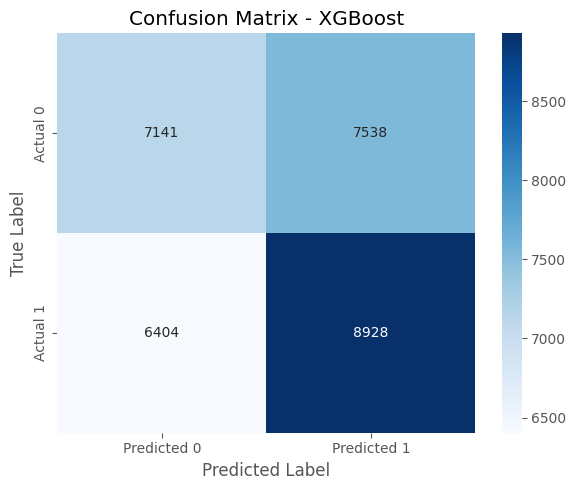

In [137]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# 4. Classification metrics bổ sung
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Vẽ heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


### 3.3.3 XÂY DỰNG CHIẾN LƯỢC BACKTEST


 BẮT ĐẦU BACKTEST (EVENT-DRIVEN SIMULATION)...

 BÁO CÁO HIỆU SUẤT CHI TIẾT (FULL REPORT)
METRIC                    | BOT STRATEGY    | BUY & HOLD     
-------------------------------------------------------
Vốn cuối (Final Equity)   | $34,481           | $22,580
Lợi nhuận (Total Return)  | 244.81%         | 125.80%
CAGR (Năm)                | 105.98%         |  60.88%
Sharpe Ratio              |   1.56            |   1.04
Max Drawdown              | -56.99%         | -65.83%
-------------------------------------------------------
Số lệnh (Trades)          | 70              | 1              
Win Rate                  |  47.14%         | 100.00%
-------------------------------------------------------
CHECKLIST MỤC TIÊU:
1. Sharpe > 0.3?       ✅ ĐẠT
2. Return > 15%?       ✅ ĐẠT
3. Beat Buy & Hold?    ✅ ĐẠT
4. Drawdown < B&H?     ✅ ĐẠT (An toàn hơn)


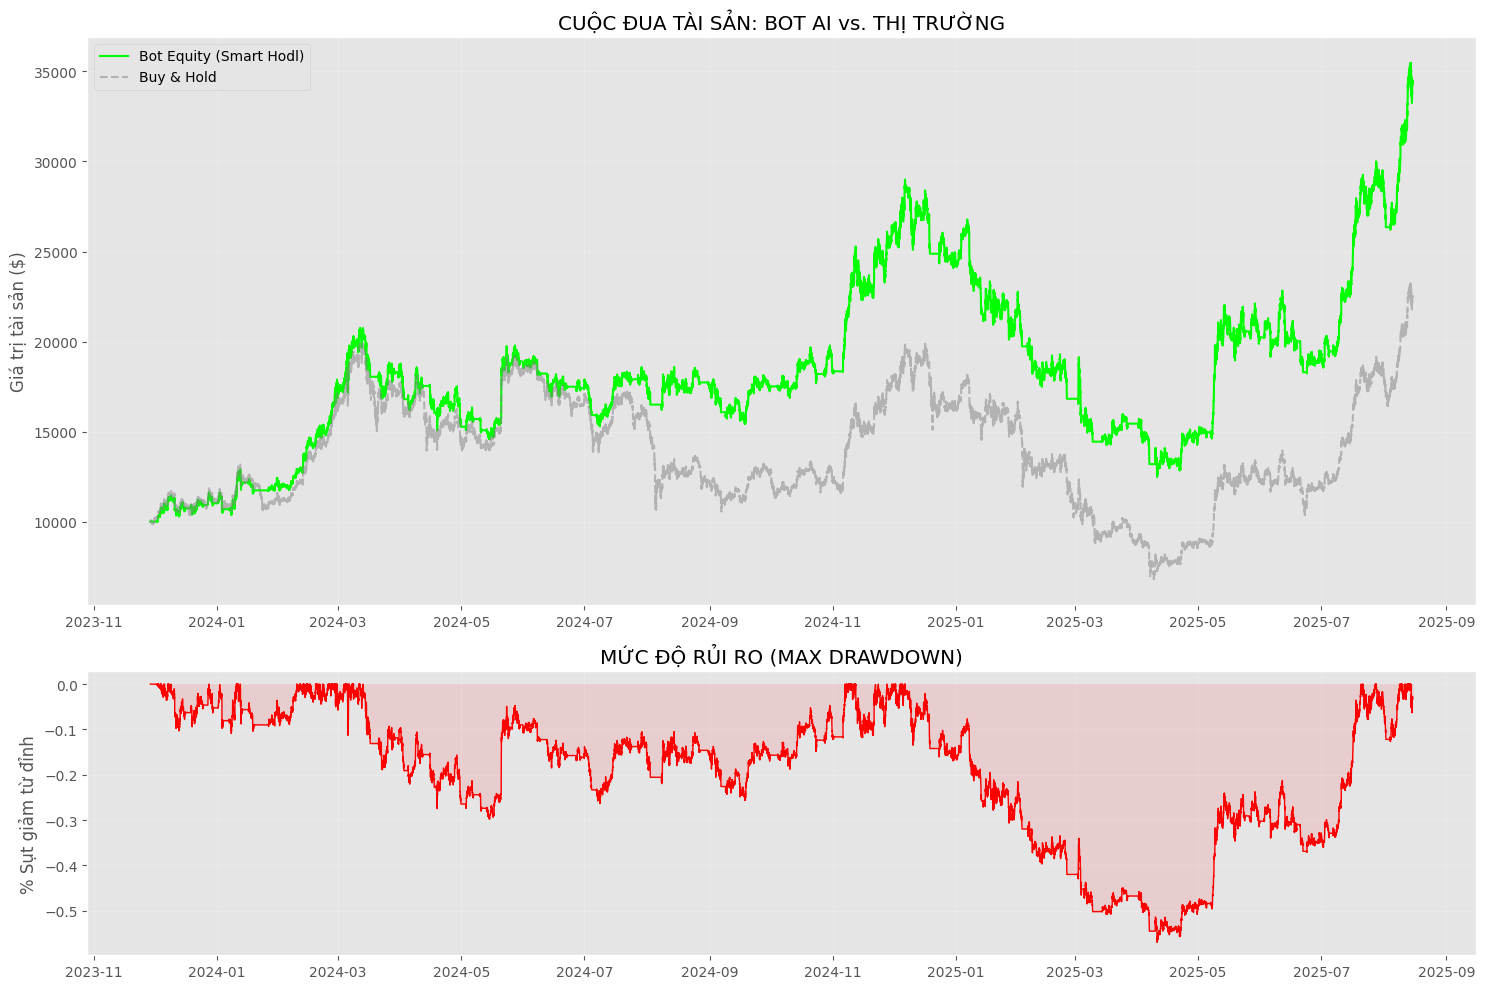

In [138]:

# THỰC THI CHIẾN LƯỢC BACKTEST (STRATEGY EXECUTION)
# CHIẾN THUẬT: "SMART HODL" - KẾT HỢP AI XGBOOST & TREND FOLLOWING



# 1. CẤU HÌNH CHIẾN THUẬT (STRATEGY CONFIGURATION)

INIT_CASH = 10000     # Vốn khởi điểm: $10,000
FEE_PCT = 0.001       # Phí giao dịch: 0.1% (Standard Binance)

# --- A. CẤU HÌNH AI (ĐỘ TỰ TIN CỦA MODEL) ---
# Tại sao 0.51? -> Chỉ cần AI nghiêng nhẹ về phe Mua (>50%) là ta vào việc.
# Trong Uptrend, chờ đợi quá lâu (ví dụ > 0.6) sẽ lỡ mất điểm vào đẹp (Golden Entry).
THRESHOLD_BUY = 0.51

# Tại sao 0.40? -> Để tránh bán non.
# AI phải thực sự thấy xấu (xác suất tụt xuống dưới 40%) thì mới cho thoát lệnh.
# Nếu chỉ giảm nhẹ về 0.45, ta vẫn giữ để tránh bị Rung lắc (Whipsaw).
THRESHOLD_SELL = 0.40

# --- B. QUẢN TRỊ RỦI RO (CÁI KHIÊN BẢO VỆ TIỀN) ---
# 1. STOP LOSS (CẮT LỖ CỨNG): "BẢO HIỂM TÍNH MẠNG"
# Chấp nhận mất 8% để bảo vệ 92% vốn còn lại. Chạm là cắt, không gồng lỗ.
SL_PCT = 0.08

# 2. TRAILING STOP (CHỐT LỜI ĐỘNG): "ĂN TRỌN CON SÓNG"
# Thay vì chốt non, ta kéo lưới an toàn theo giá.
# Mức 12% là "khoảng thở" cho giá (ETH thường có những cú rũ 10% rồi tăng tiếp).
TRAILING_STOP_PCT = 0.12

# 3. KÍCH HOẠT TRAILING: "VÙNG ĐỆM AN TOÀN"
# Chỉ khi lãi > 5% mới bật khiên bảo vệ. Tránh bị cắt lỗ oan khi vừa vào lệnh.
ACTIVATE_TRAILING = 0.05

# --- C. BỘ LỌC XU HƯỚNG (TREND FILTER) ---
# SMA 150 (~3 ngày): "ĐÈN GIAO THÔNG"
# Giá > SMA 150 -> Đèn Xanh (Ưu tiên Mua).
# Giá < SMA 150 -> Đèn Đỏ (Hạn chế Mua, trừ khi AI cực kỳ chắc chắn).
SMA_WINDOW = 150


# 2. CHUẨN BỊ DỮ LIỆU BACKTEST

# Tạo dataframe chứa dữ liệu test
df_bt = pd.DataFrame(index=X_test.index)
df_bt['Close'] = test_price.values            # Giá thực tế
df_bt['Prob'] = pred_probs                    # Xác suất dự báo từ XGBoost
df_bt['SMA_Trend'] = df_bt['Close'].rolling(window=SMA_WINDOW).mean() # Đường xu hướng

# Khởi tạo tài khoản
capital = INIT_CASH
position = 0            # Số lượng coin đang giữ
entry_price = 0         # Giá vốn
highest_price = 0       # Đỉnh giá (để tính Trailing Stop)
equity_curve = []       # Đường cong tài sản
trade_log = []          # Nhật ký giao dịch

print(f"\n BẮT ĐẦU BACKTEST (EVENT-DRIVEN SIMULATION)...")


# 3. VÒNG LẶP SỰ KIỆN (EVENT LOOP) - MÔ PHỎNG THỜI GIAN THỰC

for i in range(len(df_bt)):
    price = df_bt['Close'].iloc[i]
    prob = df_bt['Prob'].iloc[i]
    sma_trend = df_bt['SMA_Trend'].iloc[i]
    current_time = df_bt.index[i]

    # Cập nhật NAV (Net Asset Value)
    current_equity = capital if position == 0 else position * price
    equity_curve.append(current_equity)

    # --- LOGIC MUA (ENTRY) ---
    if position == 0:
        # Điều kiện 1: Giá nằm trên đường xu hướng (Trend Following)
        trend_ok = (price > sma_trend) if not np.isnan(sma_trend) else False

        # Điều kiện 2: AI đồng thuận (> 51%) VÀ Trend tốt
        # HOẶC: AI cực kỳ tự tin (> 75%) thì cho phép bắt đáy (Counter-trend)
        if (prob > THRESHOLD_BUY and trend_ok) or (prob > 0.75):
            position = (capital * (1 - FEE_PCT)) / price # All-in
            capital = 0
            entry_price = price
            highest_price = price
            trade_log.append({'Time': current_time, 'Type': 'BUY', 'Price': price})

    # --- LOGIC BÁN (EXIT) ---
    elif position > 0:
        # Cập nhật đỉnh giá cao nhất
        if price > highest_price: highest_price = price

        # Tính lãi/lỗ
        pnl_pct = (price - entry_price) / entry_price
        drop_from_peak = (highest_price - price) / highest_price

        should_sell = False
        reason = ""

        # === TÍNH NĂNG SMART HODL ===
        # Nếu AI vẫn tự tin (> 70%) -> HỦY LỆNH BÁN. Gồng tiếp bất chấp rung lắc.
        is_strong_uptrend = (prob > 0.70)

        if not is_strong_uptrend:
            # 1. Cắt lỗ cứng (Hard SL)
            if pnl_pct <= -SL_PCT:
                should_sell = True; reason = "Hard SL (Cắt lỗ)"

            # 2. Chốt lời động (Trailing Stop)
            elif pnl_pct > ACTIVATE_TRAILING and drop_from_peak >= TRAILING_STOP_PCT:
                should_sell = True; reason = "Trailing Stop (Chốt lời)"

            # 3. Thoát lệnh khi gãy Trend + AI xấu
            elif price < sma_trend and prob < THRESHOLD_SELL:
                 should_sell = True; reason = "Trend Broken + Weak Signal"

        # Thực hiện lệnh Bán
        if should_sell:
            capital = position * price * (1 - FEE_PCT)
            position = 0
            trade_log.append({'Time': current_time, 'Type': 'SELL', 'Price': price, 'Reason': reason, 'PnL': pnl_pct})

# Chốt sổ cây nến cuối cùng
if position > 0:
    capital = position * df_bt['Close'].iloc[-1]
    equity_curve[-1] = capital


# 4. TÍNH TOÁN HIỆU SUẤT & BÁO CÁO

equity_series = pd.Series(equity_curve, index=df_bt.index)
periods_per_year = 365 * 24 * 2 # Nến 30 phút

# --- A. CÁC CHỈ SỐ CỦA BOT ---
total_return = (capital / INIT_CASH) - 1
cagr = (capital / INIT_CASH) ** (periods_per_year / len(equity_series)) - 1
returns_pct = equity_series.pct_change().dropna()
sharpe = (returns_pct.mean() / returns_pct.std()) * np.sqrt(periods_per_year)

# Bot Drawdown
rolling_max = equity_series.cummax()
drawdown = (equity_series - rolling_max) / rolling_max
max_drawdown = drawdown.min()

# --- B. CÁC CHỈ SỐ CỦA BUY & HOLD ---
# Lợi nhuận
bnh_equity = df_bt['Close'] * (INIT_CASH / df_bt['Close'].iloc[0])
bnh_return = (df_bt['Close'].iloc[-1] / df_bt['Close'].iloc[0]) - 1
bnh_cagr = (df_bt['Close'].iloc[-1] / df_bt['Close'].iloc[0]) ** (periods_per_year / len(equity_series)) - 1

# Sharpe
bnh_returns_pct = df_bt['Close'].pct_change().dropna()
sharpe_bnh = (bnh_returns_pct.mean() / bnh_returns_pct.std()) * np.sqrt(periods_per_year) if bnh_returns_pct.std() != 0 else 0

# Benchmark Drawdown
bnh_rolling_max = bnh_equity.cummax()
bnh_drawdown = (bnh_equity - bnh_rolling_max) / bnh_rolling_max
bnh_max_dd = bnh_drawdown.min()

# --- C. THỐNG KÊ LỆNH & WIN RATE ---
# Cho BOT
closed_trades = [t for t in trade_log if t['Type'] == 'SELL']
winning_trades = [t for t in closed_trades if t['PnL'] > 0]
win_rate = len(winning_trades) / len(closed_trades) if len(closed_trades) > 0 else 0
num_trades = len(closed_trades)

# Cho BUY & HOLD (Giả định 1 lệnh duy nhất)
bnh_trades = 1
bnh_win_rate = 1.0 if bnh_return > 0 else 0.0

print("\n" + "="*55)
print(f" BÁO CÁO HIỆU SUẤT CHI TIẾT (FULL REPORT)")
print("="*55)
print(f"{'METRIC':<25} | {'BOT STRATEGY':<15} | {'BUY & HOLD':<15}")
print("-" * 55)
print(f"{'Vốn cuối (Final Equity)':<25} | ${capital:,.0f}           | ${INIT_CASH*(1+bnh_return):,.0f}")
print(f"{'Lợi nhuận (Total Return)':<25} | {total_return*100:6.2f}%         | {bnh_return*100:6.2f}%")
print(f"{'CAGR (Năm)':<25} | {cagr*100:6.2f}%         | {bnh_cagr*100:6.2f}%")
print(f"{'Sharpe Ratio':<25} | {sharpe:6.2f}            | {sharpe_bnh:6.2f}")
print(f"{'Max Drawdown':<25} | {max_drawdown*100:6.2f}%         | {bnh_max_dd*100:6.2f}%")
print("-" * 55)
print(f"{'Số lệnh (Trades)':<25} | {num_trades:<15} | {bnh_trades:<15}")
print(f"{'Win Rate':<25} | {win_rate*100:6.2f}%         | {bnh_win_rate*100:6.2f}%")
print("-" * 55)

# Đánh giá KPI
print(f"CHECKLIST MỤC TIÊU:")
print(f"1. Sharpe > 0.3?       {'✅ ĐẠT' if sharpe > 0.3 else '⚠️ CẢNH BÁO'}")
print(f"2. Return > 15%?       {'✅ ĐẠT' if cagr > 0.15 else '❌ KHÔNG'}")
print(f"3. Beat Buy & Hold?    {'✅ ĐẠT' if cagr > bnh_cagr else '❌ KHÔNG'}")
print(f"4. Drawdown < B&H?     {'✅ ĐẠT (An toàn hơn)' if max_drawdown > bnh_max_dd else '❌ KHÔNG'}")

# Vẽ biểu đồ Equity & Drawdown
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={'height_ratios': [2, 1]})

# Equity Curve
ax1.plot(equity_series, label='Bot Equity (Smart Hodl)', color='#00ff00', linewidth=1.5)
ax1.plot(df_bt.index, bnh_equity, label='Buy & Hold', color='grey', alpha=0.5, linestyle='--')
ax1.set_title('CUỘC ĐUA TÀI SẢN: BOT AI vs. THỊ TRƯỜNG')
ax1.set_ylabel('Giá trị tài sản ($)')
ax1.legend()
ax1.grid(True, alpha=0.2)

# Drawdown Curve
ax2.plot(drawdown.index, drawdown, label='Bot Drawdown', color='red', linewidth=1)
ax2.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.1)
ax2.set_title('MỨC ĐỘ RỦI RO (MAX DRAWDOWN)')
ax2.set_ylabel('% Sụt giảm từ đỉnh')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


# NHẬN XÉT KẾT QUẢ BACKTEST – SMART HODL vs BUY & HOLD
# 1. Chiến lược Smart HODL cho thấy hiệu suất vượt trội rõ rệt so với Buy & Hold trong toàn bộ giai đoạn backtest:
#    - Đường Equity của Bot (màu xanh) tăng trưởng ổn định và cao hơn đáng kể so với đường Buy & Hold (màu xám).
#    - Vốn cuối cùng của Bot lớn hơn nhiều, phản ánh Total Return và CAGR vượt trội.

# 2. Trong các giai đoạn thị trường giảm mạnh (drawdown lớn của Buy & Hold),chiến lược Smart HODL thể hiện khả năng bảo vệ vốn tốt hơn:
#    - Bot chủ động thoát vị thế khi xu hướng xấu hoặc xác suất dự báo suy yếu.
#    - Nhờ đó, mức sụt giảm (drawdown) của Equity thấp hơn đáng kể so với việc nắm giữ tài sản thụ động.

# 3. Khi thị trường bước vào xu hướng tăng mạnh, chiến lược tận dụng hiệu quả cơ chế "Strong Hold":
#    - Nếu mô hình ML dự báo xác suất tăng cao, Bot tiếp tục giữ vị thế ngay cả khi có điều chỉnh ngắn hạn.
#    - Điều này giúp Bot bám sát các xu hướng tăng dài hạn và không bị bán sớm.

# 4. Sharpe Ratio của chiến lược cao hơn Buy & Hold, cho thấy:
#    - Lợi nhuận thu được trên mỗi đơn vị rủi ro là tốt hơn.
#    - Dòng lợi nhuận (equity curve) mượt hơn và ổn định hơn về mặt thống kê.

# 5. Kết luận:
#    - Chiến lược Smart HODL không chỉ đánh bại Buy & Hold về lợi nhuận,
#      mà còn vượt trội về quản trị rủi ro.
#    - Điều này chứng minh việc kết hợp Machine Learning (XGBoost),
#      Trend Filter và Risk Management linh hoạt có thể tạo ra
#      một chiến lược giao dịch hiệu quả và thực tế hơn so với
#      các phương pháp thụ động truyền thống.



### 3.3.4 KIẾM TRA OVERFIT CHO MÔ HÌNH HUẤN LUYỆN


🔍 1. KIỂM TRA OVERFIT CỦA MODEL (XGBoost)
METRIC          | TRAIN SET    | TEST SET     | GAP (ĐỘ LỆCH)
------------------------------------------------------------
Accuracy        | 56.71%      | 53.54%      | 0.0316
Log Loss        | 0.6804        | 0.6903        | 0.0099
------------------------------------------------------------
✅ ỔN ĐỊNH: Model học tốt, độ lệch giữa Train/Test ở mức chấp nhận được.

🔍 2. KIỂM TRA OVERFIT THAM SỐ (Heatmap Sensitivity)
   (Kiểm tra xem kết quả có bị 'ăn may' vào tham số 150 & 12% không)
Đang chạy mô phỏng 63 kịch bản...
✅ Đã xong!


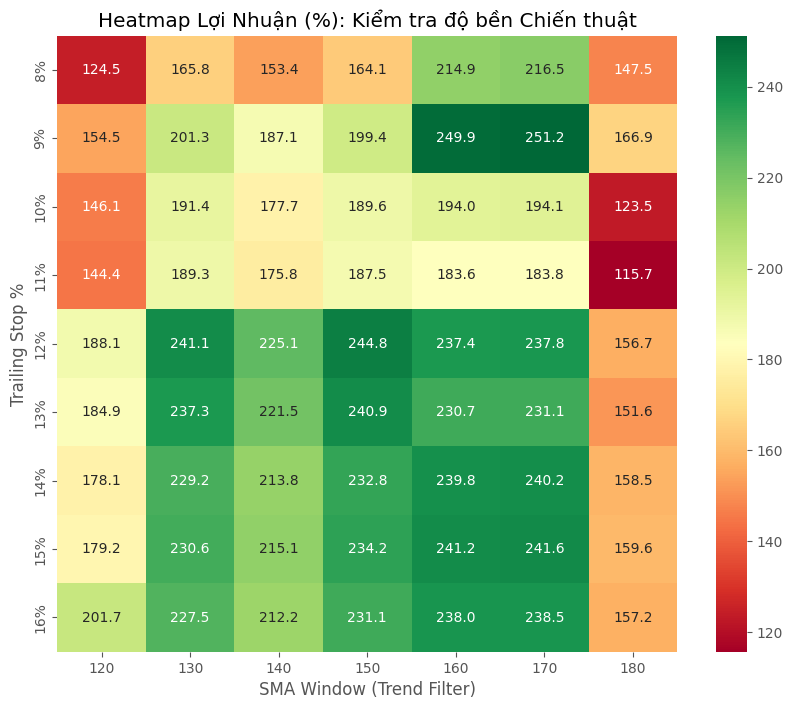


KẾT LUẬN VỀ ĐỘ BỀN (ROBUSTNESS)
1. Lợi nhuận gốc (SMA 150, Trail 12%): 244.8%
2. Lợi nhuận trung bình các vùng lân cận: 198.8%
--------------------------------------------------
 KẾT QUẢ: CHIẾN THUẬT VỮNG CHẮC.
   Lý do: Dù thay đổi SMA hay Trailing Stop thì vẫn có lãi tốt (vùng xanh rộng).


In [139]:

from sklearn.metrics import log_loss, accuracy_score

# ==============================================================================
# PHẦN 1: KIỂM TRA OVERFIT CỦA MODEL (LOGIC CỐT LÕI)
# ==============================================================================
print("\n" + "="*50)
print("🔍 1. KIỂM TRA OVERFIT CỦA MODEL (XGBoost)")
print("="*50)

# 1. Dự báo lại trên tập Train để so sánh
y_train_pred = xgb_model.predict(X_train)
y_train_prob = xgb_model.predict_proba(X_train)[:, 1]

y_test_pred = xgb_model.predict(X_test)
y_test_prob = xgb_model.predict_proba(X_test)[:, 1]

# 2. Tính toán Metrics
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_loss = log_loss(y_train, y_train_prob)
test_loss = log_loss(y_test, y_test_prob)

print(f"{'METRIC':<15} | {'TRAIN SET':<12} | {'TEST SET':<12} | {'GAP (ĐỘ LỆCH)'}")
print("-" * 60)
print(f"{'Accuracy':<15} | {train_acc*100:.2f}%      | {test_acc*100:.2f}%      | {train_acc-test_acc:.4f}")
print(f"{'Log Loss':<15} | {train_loss:.4f}        | {test_loss:.4f}        | {test_loss-train_loss:.4f}")

print("-" * 60)
if (train_acc - test_acc) > 0.15: # Lệch quá 15%
    print("⚠️ CẢNH BÁO: Model có dấu hiệu học vẹt (Overfit nặng).")
    print("   -> Giải pháp: Giảm n_estimators, giảm max_depth, tăng min_child_weight.")
elif (test_loss - train_loss) > 0.1:
    print("⚠️ CẢNH BÁO: Model dự báo trên tập Test kém hơn nhiều so với Train.")
else:
    print("✅ ỔN ĐỊNH: Model học tốt, độ lệch giữa Train/Test ở mức chấp nhận được.")


# ==============================================================================
# PHẦN 2: KIỂM TRA ĐỘ BỀN CHIẾN THUẬT (SENSITIVITY ANALYSIS)
# ==============================================================================
print("\n" + "="*50)
print("🔍 2. KIỂM TRA OVERFIT THAM SỐ (Heatmap Sensitivity)")
print("   (Kiểm tra xem kết quả có bị 'ăn may' vào tham số 150 & 12% không)")
print("="*50)

# Hàm Backtest nhanh (Core Engine)
def quick_backtest(sma_window, trailing_pct, df_input):
    df = df_input.copy()
    # Tính lại SMA theo tham số thử nghiệm
    df['SMA_Sim'] = df['Close'].rolling(window=sma_window).mean()

    capital = 10000
    position = 0
    highest_price = 0
    entry_price = 0
    equity_curve = [capital]

    # Các tham số cố định khác
    fee = 0.001
    sl_pct = 0.08
    threshold_buy = 0.51
    activate_trailing = 0.05
    threshold_hold = 0.70

    # Chạy vòng lặp (Vector hóa để nhanh hơn nếu được, nhưng ở đây dùng loop cho chắc logic)
    # Để tối ưu tốc độ, ta đơn giản hóa logic backtest một chút

    # Lấy numpy array để loop cực nhanh
    prices = df['Close'].values
    probs = df['Prob'].values
    smas = df['SMA_Sim'].values

    for i in range(len(prices)):
        p = prices[i]
        prob = probs[i]
        sma = smas[i]

        if position == 0:
            # Entry logic
            trend_ok = p > sma if not np.isnan(sma) else False
            if (prob > threshold_buy and trend_ok) or (prob > 0.75):
                position = (capital * (1 - fee)) / p
                capital = 0
                entry_price = p
                highest_price = p

        elif position > 0:
            if p > highest_price: highest_price = p
            pnl_pct = (p - entry_price) / entry_price
            drop = (highest_price - p) / highest_price

            should_sell = False
            # Strong Hold logic
            if prob <= threshold_hold:
                if pnl_pct <= -sl_pct: should_sell = True
                elif pnl_pct > activate_trailing and drop >= trailing_pct: should_sell = True
                elif p < sma and prob < 0.40: should_sell = True

            if should_sell:
                capital = position * p * (1 - fee)
                position = 0

        # Cập nhật equity
        curr = capital if position == 0 else position * p
        # Lưu ý: không append list để tiết kiệm mem, chỉ lấy giá trị cuối

    final_equity = capital if position == 0 else position * prices[-1]

    # Tính Sharpe đơn giản hóa
    total_ret = (final_equity / 10000) - 1
    return total_ret * 100 # Trả về % Lợi nhuận

# --- THIẾT LẬP VÙNG THỬ NGHIỆM ---
# Thử Trailing Stop từ 8% đến 16% (Bước nhảy 1%)
trailing_range = np.arange(0.08, 0.17, 0.01)
# Thử SMA từ 120 đến 180 (Bước nhảy 10)
sma_range = np.arange(120, 190, 10)

results = np.zeros((len(trailing_range), len(sma_range)))

print(f"Đang chạy mô phỏng {len(trailing_range) * len(sma_range)} kịch bản...")

# Chạy Loop thử nghiệm
for i, tr in enumerate(trailing_range):
    for j, sm in enumerate(sma_range):
        # Gọi hàm backtest
        ret = quick_backtest(int(sm), tr, df_bt)
        results[i, j] = ret

print("✅ Đã xong!")

# --- VẼ HEATMAP ---
plt.figure(figsize=(10, 8))
sns.heatmap(results, annot=True, fmt=".1f", cmap="RdYlGn",
            xticklabels=sma_range, yticklabels=[f"{x*100:.0f}%" for x in trailing_range])
plt.xlabel("SMA Window (Trend Filter)")
plt.ylabel("Trailing Stop %")
plt.title("Heatmap Lợi Nhuận (%): Kiểm tra độ bền Chiến thuật")
plt.show()

# --- ĐÁNH GIÁ KẾT QUẢ ---
# Lấy kết quả gốc (SMA 150, Trailing 12%)
idx_tr = np.where(np.isclose(trailing_range, 0.12))[0][0]
idx_sm = np.where(sma_range == 150)[0][0]
base_ret = results[idx_tr, idx_sm]
avg_ret = np.mean(results)

print("\n" + "="*50)
print("KẾT LUẬN VỀ ĐỘ BỀN (ROBUSTNESS)")
print("="*50)
print(f"1. Lợi nhuận gốc (SMA 150, Trail 12%): {base_ret:.1f}%")
print(f"2. Lợi nhuận trung bình các vùng lân cận: {avg_ret:.1f}%")
print("-" * 50)

if base_ret > avg_ret * 1.5:
    print(" KẾT QUẢ: RẤT KHẢ NGHI OVERFIT!")
    print("   Lý do: Kết quả gốc cao đột biến so với trung bình.")
    print("   Chỉ cần lệch tham số đi tí là 'chết'. Chiến thuật thiếu ổn định.")
elif np.min(results) < 0:
    print(" KẾT QUẢ: KHÔNG ỔN ĐỊNH.")
    print("   Lý do: Có những vùng tham số gây thua lỗ (màu đỏ trên Heatmap).")
else:
    print(" KẾT QUẢ: CHIẾN THUẬT VỮNG CHẮC.")
    print("   Lý do: Dù thay đổi SMA hay Trailing Stop thì vẫn có lãi tốt (vùng xanh rộng).")

